<a href="https://colab.research.google.com/github/vs-152/FL-Contributions-Incentives-Project/blob/main/ISO_CIFAR10_OR_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ─────────────────────────────────────────────────────────────
#  Imports
# ─────────────────────────────────────────────────────────────
import os
import copy
import time
import glob
import shutil
import tempfile
from itertools import chain, combinations

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.utils.data.sampler import SubsetRandomSampler
from sklearn.model_selection import StratifiedShuffleSplit
from scipy.special import comb
import matplotlib.pyplot as plt
from tqdm import tqdm
import nibabel as nib
import pulp
import onnxruntime
import random

# ─────────────────────────────────────────────────────────────
#  MONAI
# ─────────────────────────────────────────────────────────────
from monai.config import print_config
from monai.utils import set_determinism
from monai.data import CacheDataset, DataLoader, decollate_batch
from monai.handlers.utils import from_engine
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.networks.nets import SegResNet
from monai.apps import DecathlonDataset
from monai.transforms import (
    Activations,
    Activationsd,
    AsDiscrete,
    AsDiscreted,
    Compose,
    EnsureChannelFirstd,
    EnsureTyped,
    Invertd,
    LoadImaged,
    MapTransform,
    NormalizeIntensityd,
    Orientationd,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandSpatialCropd,
    ScaleIntensityd,
    Spacingd,
    SelectItemsd
)

# ─────────────────────────────────────────────────────────────
#  Custom Modules
# ─────────────────────────────────────────────────────────────
from utils import *

# ─────────────────────────────────────────────────────────────
#  Device & Setup
# ─────────────────────────────────────────────────────────────
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print_config()
set_determinism(seed=0)


2026-03-06 13:35:02.880175748 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


MONAI version: 1.6.dev2542
Numpy version: 2.1.2
Pytorch version: 2.8.0+cu126
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 612f3dd3cba4d73cfcea4b5329079e20aa31523d
MONAI __file__: /home/<username>/miniconda3/envs/m_quant_py310/lib/python3.10/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: 5.4.4
Nibabel version: 5.3.2
scikit-image version: 0.25.2
scipy version: 1.15.3
Pillow version: 11.0.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.23.0+cu126
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.0.0
pandas version: 2.3.2
einops version: 0.8.1
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For d

In [2]:
# Corrected conversion for FeTS labels
class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):
    """
    FeTS/BraTS label mapping (ints on disk): 0=background, 1=NCR/NET, 2=edema, 4=enhancing (ET)
    Build 3-channel multi-label [TC, WT, ET]:
      TC = (label==1) OR (label==4)
      WT = (label==1) OR (label==2) OR (label==4)
      ET = (label==4)
    """
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            lab = d[key]
            tc = torch.logical_or(lab == 1, lab == 4)
            wt = torch.logical_or(torch.logical_or(lab == 1, lab == 2), lab == 4)
            et = (lab == 4)
            d[key] = torch.stack([tc, wt, et], dim=0).float()
        return d

simclr_base_transform = Compose(
    [
        LoadImaged(keys=["image"]),
        EnsureChannelFirstd(keys="image"),
        EnsureTyped(keys="image"),
        Orientationd(keys="image", axcodes="RAS"),
        Spacingd(
            keys="image",
            pixdim=(1.0, 1.0, 1.0),
            mode="bilinear",
        ),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ]
)

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# -----------------------------------------------------------
# 0. paths & meta-data (unchanged) ---------------------------
# -----------------------------------------------------------
BRATS_DIR = "/mnt/d/Datasets/FETS_data/MICCAI_FeTS2022_TrainingData"
CSV_PATH  = f"{BRATS_DIR}/partitioning_1.csv"
MODALITIES = ["flair", "t1", "t1ce", "t2"]
LABEL_KEY  = "seg"

# -----------------------------------------------------------
# 1. read partition file  ➜  { id : [subjects] } ------------
# -----------------------------------------------------------
part_df = pd.read_csv(CSV_PATH)

# --- compute subject counts per site -----------------------
site_counts = (
    part_df.groupby("Partition_ID")["Subject_ID"]
           .nunique()
)

TOP_K = 6  # keep 6 most populated sites for training

# site IDs for training (top-K by subject count)
TRAIN_CENTRES = set(
    site_counts.sort_values(ascending=False)
               .head(TOP_K)
               .index.tolist()
)

# everything else is validation
VAL_CENTRES = set(site_counts.index) - TRAIN_CENTRES

print("Train centres (top 6 by subject count):")
print(site_counts.loc[sorted(TRAIN_CENTRES)])
print("\nValidation centres (remaining):")
print(site_counts.loc[sorted(VAL_CENTRES)])

# map centre → list of subject IDs
partition_map = (
    part_df.groupby("Partition_ID")["Subject_ID"]
           .apply(list).to_dict()
)

# split once, reuse everywhere
train_partitions = {
    cid: sids for cid, sids in partition_map.items()
    if cid in TRAIN_CENTRES
}
val_subjects = sum((partition_map[cid] for cid in VAL_CENTRES), [])


# -----------------------------------------------------------
# 2. helper to build MONAI-style record dicts ----------------
# -----------------------------------------------------------
def build_simclr_records(subject_ids):
    recs = []
    for sid in subject_ids:
        sdir = f"{BRATS_DIR}/{sid}"
        images = [f"{sdir}/{sid}_{m}.nii.gz" for m in MODALITIES]
        recs.append({"image": images})
    return recs

# -----------------------------------------------------------
# 3. MONAI CacheDatasets ------------------------------------
# -----------------------------------------------------------
FRAC, SEED = 1, 42   # FRAC for subsampling within each site
rng = random.Random(SEED)

simclr_base_datasets = {}

for cid, subj_ids in train_partitions.items():
    simclr_base_datasets[cid] = CacheDataset(
        build_simclr_records(subj_ids),
        transform=simclr_base_transform,
        cache_rate=1,
    )

Train centres (top 6 by subject count):
Partition_ID
1     511
4      47
6      34
13     35
18    382
21     35
Name: Subject_ID, dtype: int64

Validation centres (remaining):
Partition_ID
2      6
3     15
5     22
7     12
8      8
9      4
10     8
11    14
12    11
14     6
15    13
16    30
17     9
19     4
20    33
22     7
23     5
Name: Subject_ID, dtype: int64


Loading dataset: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 35/35 [02:31<00:00,  4.32s/it]


# SimCLR data handling

In [4]:
# ─────────────────────────────────────────────────────────────
#  SimCLR Contrastive Transform (image only)
# ─────────────────────────────────────────────────────────────

from monai.transforms import RandRotate90d, RandGaussianNoised

simclr_2d_transform = Compose(
    [
        EnsureTyped(keys="image"),
        RandFlipd(keys="image", prob=0.5, spatial_axis=0),
        RandFlipd(keys="image", prob=0.5, spatial_axis=1),
        RandRotate90d(keys="image", prob=0.5),
        # RandScaleIntensityd(keys="image", factors=0.1, prob=0.8),
        # RandShiftIntensityd(keys="image", offsets=0.1, prob=0.8),
        # RandGaussianNoised(keys="image", prob=0.5),
    ]
)

class SimCLR2DDataset(Dataset):
    def __init__(self, monai_dataset, transform, slices_per_volume=20):
        self.dataset = monai_dataset
        self.transform = transform
        self.slices_per_volume = slices_per_volume

    def __len__(self):
        return len(self.dataset) * self.slices_per_volume

    def __getitem__(self, idx):
        # map idx back to volume index
        vol_idx = idx % len(self.dataset)
        data = self.dataset[vol_idx]

        img = data["image"]  # [C, H, W, D]

        depth = img.shape[-1]
        z = torch.randint(0, depth, (1,)).item()
        slice_2d = img[..., z]

        slice_dict = {"image": slice_2d}

        view1 = self.transform(slice_dict)["image"]
        view2 = self.transform(slice_dict)["image"]

        return view1, view2
        
simclr_train_datasets = {
    cid: SimCLR2DDataset(ds, simclr_2d_transform, slices_per_volume=20)
    for cid, ds in simclr_base_datasets.items()
}

from torch.utils.data import ConcatDataset

simclr_pooled_dataset = ConcatDataset(
    list(simclr_train_datasets.values())
)

simclr_loader = DataLoader(
    simclr_pooled_dataset,
    batch_size=32,   # now we can go bigger
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

In [5]:
v1, v2 = next(iter(simclr_loader))
print(v1.shape, v2.shape)
print("Total SimCLR samples:", len(simclr_pooled_dataset))
print("Batches per epoch:", len(simclr_loader))

torch.Size([32, 4, 240, 240]) torch.Size([32, 4, 240, 240])
Total SimCLR samples: 20880
Batches per epoch: 653


#  SimCLR model

Step 1 — Define Encoder + Projection Head

In [6]:
# ─────────────────────────────────────────────────────────────
#  SimCLR Model (2D)
# ─────────────────────────────────────────────────────────────
from monai.networks.nets import resnet

class SimCLR2D(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()

        # 2D ResNet18
        self.encoder = resnet.resnet18(
            spatial_dims=2,
            n_input_channels=4,  # 4 MRI modalities
            num_classes=512
        )

        self.encoder.fc = nn.Identity()

        self.projector = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return h, z


model = SimCLR2D().to(device)

Step 2 — Implement NT-Xent Loss

In [7]:
import torch.nn.functional as F

def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)

    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    representations = torch.cat([z1, z2], dim=0)

    similarity_matrix = torch.matmul(representations, representations.T)

    labels = torch.arange(batch_size).to(device)
    labels = torch.cat([labels, labels], dim=0)

    mask = torch.eye(labels.shape[0], dtype=torch.bool).to(device)
    similarity_matrix = similarity_matrix[~mask].view(labels.shape[0], -1)

    positives = torch.cat([
        torch.sum(z1 * z2, dim=1),
        torch.sum(z2 * z1, dim=1)
    ], dim=0)

    logits = similarity_matrix / temperature
    positives = positives / temperature

    loss = -torch.log(
        torch.exp(positives) /
        torch.sum(torch.exp(logits), dim=1)
    )

    return loss.mean()

Step 3 - Training Loop - Comment out to just run visuals

In [8]:
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer,
#     T_max=50
# )

# epochs = 50
# best_loss = float("inf")

# for epoch in range(epochs):
#     model.train()
#     total_loss = 0

#     for v1, v2 in tqdm(simclr_loader):
#         v1 = v1.to(device)
#         v2 = v2.to(device)

#         _, z1 = model(v1)
#         _, z2 = model(v2)

#         loss = nt_xent_loss(z1, z2)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     # ---- end of epoch ----
#     scheduler.step()

#     epoch_loss = total_loss / len(simclr_loader)

#     print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

#     if epoch_loss < best_loss:
#         best_loss = epoch_loss
#         torch.save(model.state_dict(), "./simclr_models/simclr_2d_best.pt")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 653/653 [02:46<00:00,  3.93it/s]


Epoch 1, Loss: 2.4798


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 653/653 [02:44<00:00,  3.97it/s]


Epoch 2, Loss: 2.3693


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 653/653 [02:44<00:00,  3.97it/s]


...

Epoch 48, Loss: 2.2704


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 653/653 [02:44<00:00,  3.97it/s]


Epoch 49, Loss: 2.2683


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 653/653 [02:44<00:00,  3.97it/s]


Epoch 50, Loss: 2.2669


In [9]:
model.load_state_dict(torch.load("./simclr_models/simclr_2d_best.pt"))
model.eval()

SimCLR2D(
  (encoder): ResNet(
    (conv1): Conv2d(4, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): ResNetBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): ResNetBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_ru

# Build Per-Site Embedding Extractor

In [10]:
def extract_site_embeddings(site_dataset, model, device):
    loader = DataLoader(
        site_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2
    )

    all_embeddings = []

    with torch.no_grad():
        for v1, _ in loader:   # only need one view
            v1 = v1.to(device)
            h, _ = model(v1)
            all_embeddings.append(h.cpu())

    return torch.cat(all_embeddings, dim=0)

site_embeddings = {}

for cid, dataset in simclr_train_datasets.items():
    print(f"Extracting embeddings for site {cid}")
    site_embeddings[cid] = extract_site_embeddings(dataset, model, device)

Extracting embeddings for site 1
Extracting embeddings for site 4
Extracting embeddings for site 6
Extracting embeddings for site 13
Extracting embeddings for site 18
Extracting embeddings for site 21


Explained variance ratio (first 10 components):
[0.1946 0.1444 0.0935 0.0878 0.0816 0.0767 0.0585 0.0522 0.0438 0.0352]


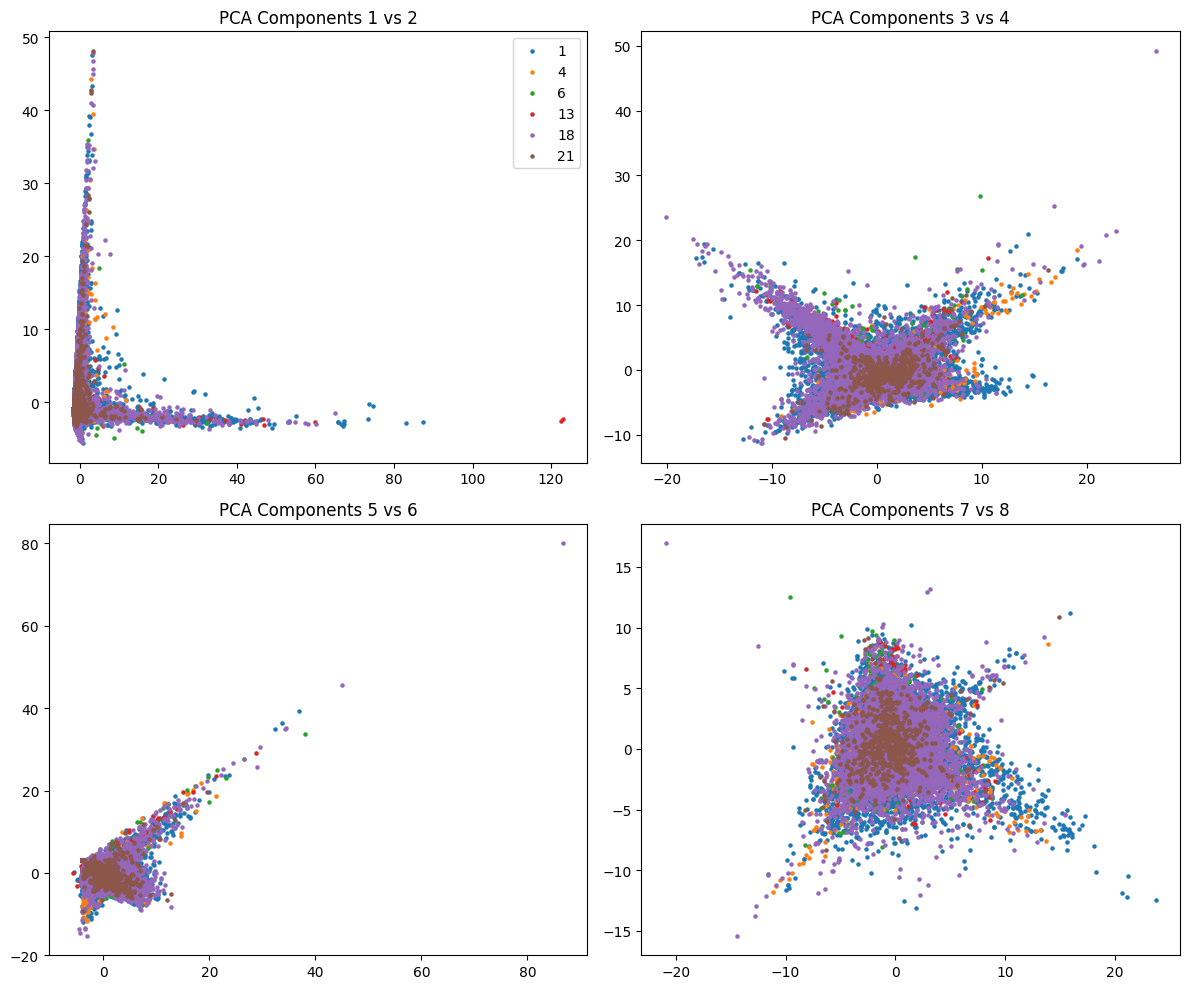

In [14]:
# ─────────────────────────────────────────────────────────────
#  PCA Exploration (different component pairs)
# ─────────────────────────────────────────────────────────────
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# --- rebuild all_embs + labels if not already in memory ---
all_embs = []
labels = []
site_ids = list(simclr_train_datasets.keys())

for i, cid in enumerate(site_ids):
    emb = site_embeddings[cid]   # tensor [N, 512]
    all_embs.append(emb)
    labels.extend([i] * emb.shape[0])

all_embs = torch.cat(all_embs).numpy()
labels = np.array(labels)

# --- PCA ---
pca = PCA(n_components=10)
proj = pca.fit_transform(all_embs)

print("Explained variance ratio (first 10 components):")
print(np.round(pca.explained_variance_ratio_, 4))

# --- Plot different component pairs ---
pairs = [(0,1), (2,3), (4,5), (6,7)]

plt.figure(figsize=(12,10))
for idx, (i, j) in enumerate(pairs, 1):
    plt.subplot(2, 2, idx)
    for k, cid in enumerate(site_ids):
        mask = labels == k
        plt.scatter(proj[mask, i], proj[mask, j], s=5, label=str(cid))
    plt.title(f"PCA Components {i+1} vs {j+1}")
    if idx == 1:
        plt.legend()
plt.tight_layout()
plt.savefig("./plots/pca_plot.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [17]:
all_embs.shape

(20880, 512)

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.


Site classification accuracy: 0.6231
Random baseline accuracy: 0.1667


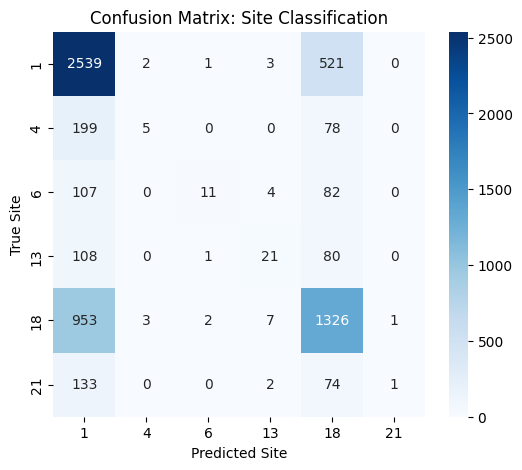

In [15]:
# ─────────────────────────────────────────────────────────────
#  Site Classification from Embeddings
# ─────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# --- Train/Test split ---
X_train, X_test, y_train, y_test = train_test_split(
    all_embs, labels, test_size=0.3, random_state=42, stratify=labels
)

# --- Train classifier ---
clf = LogisticRegression(max_iter=2000, multi_class="multinomial")
clf.fit(X_train, y_train)

# --- Evaluate ---
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Site classification accuracy: {acc:.4f}")
print(f"Random baseline accuracy: {1/len(site_ids):.4f}")

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=site_ids, yticklabels=site_ids)
plt.title("Confusion Matrix: Site Classification")
plt.xlabel("Predicted Site")
plt.ylabel("True Site")

plt.savefig("./plots/confusion_matrix_site_classification.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [18]:
# ─────────────────────────────────────────────────────────────
#  Per-Site Representation Metrics
# ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

site_ids = list(site_embeddings.keys())

metrics = []

global_mean = all_embs.mean(axis=0)

for i, cid in enumerate(site_ids):
    emb = site_embeddings[cid].numpy()
    
    # 1. Cluster Compactness (variance)
    covariance = np.cov(emb, rowvar=False)
    compactness = np.trace(covariance)   # total variance
    
    # 2. Distance to Global Centroid
    site_mean = emb.mean(axis=0)
    centroid_dist = np.linalg.norm(site_mean - global_mean)
    
    # 3. Self Classification Accuracy
    # (from confusion matrix logic)
    mask = labels == i
    y_true = labels[mask]
    y_pred_site = clf.predict(all_embs[mask])
    self_acc = accuracy_score(y_true, y_pred_site)
    
    metrics.append({
        "site": cid,
        "num_samples": emb.shape[0],
        "compactness": compactness,
        "centroid_distance": centroid_dist,
        "self_accuracy": self_acc
    })

metrics_df = pd.DataFrame(metrics).sort_values("site")
metrics_df

,site,num_samples,compactness,centroid_distance,self_accuracy
0,1,10220,123.508543,0.718898,0.835714
1,4,940,109.049894,1.568237,0.014894
2,6,680,106.981539,2.017487,0.044118
3,13,700,163.240019,2.191307,0.078571
4,18,7640,114.668718,0.855167,0.586780
5,21,700,98.012439,1.361930,0.004286
